# Guia Sprint 5: entrenamiento y evaluacion del modelo de `w`

Este notebook documenta un flujo completo para usar el algoritmo de Sprint 5 en modo regresion:

1. Cargar datos `featured`
2. Construir dataset supervisado para predecir `w` (omega)
3. Entrenar un baseline `RandomForestRegressor` con K-Fold
4. Evaluar con metricas de regresion (RMSE, MAE, R2)
5. Visualizar calidad del modelo con graficas
6. Guardar artefactos (modelo + metricas)

## Requisitos

- Ejecutar desde Python con: `numpy`, `pandas`, `scikit-learn`, `matplotlib`, `seaborn`, `joblib`
- Tener CSVs en `Doback-Data/featured`
- El notebook detecta automaticamente la raiz del repositorio

In [1]:
import sys
from pathlib import Path
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import dump

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'Scripts').exists() and (candidate / 'Doback-Data').exists():
            return candidate
    raise RuntimeError('No se encontro la raiz del repositorio desde el directorio actual')

REPO_ROOT = find_repo_root(Path.cwd().resolve())
SCRIPTS_ROOT = REPO_ROOT / 'Scripts'

if str(SCRIPTS_ROOT) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_ROOT))

from ml.feature_engineering import build_w_training_dataset, load_featured_data

print('Repo root:', REPO_ROOT)
print('Scripts root:', SCRIPTS_ROOT)

Repo root: C:\Users\alexc\Nextcloud\phd-AlexCastilla\code\LiDAR-Stability-algorithm
Scripts root: C:\Users\alexc\Nextcloud\phd-AlexCastilla\code\LiDAR-Stability-algorithm\Scripts


## 1) Configuracion del experimento

Puedes ajustar el `glob` para entrenar con un archivo, segmentos de un dia, o toda la carpeta.

In [3]:
INPUT_GLOB = 'Doback-Data/featured/DOBACK024_20250929_seg*.csv'
TARGET_COLUMN = None  # None = autodeteccion (omega_rad_s / gy / gz)
N_SPLITS = 5
RANDOM_STATE = 42

MODEL_OUT = REPO_ROOT / 'output/w_model_rf_notebook.joblib'
METRICS_OUT = REPO_ROOT / 'output/w_model_rf_notebook_metrics.json'

csv_paths = sorted(REPO_ROOT.glob(INPUT_GLOB))
print('Archivos encontrados:', len(csv_paths))
for p in csv_paths[:5]:
    print(' -', p.name)
if len(csv_paths) > 5:
    print(' - ...')

Archivos encontrados: 4
 - DOBACK024_20250929_seg10.csv
 - DOBACK024_20250929_seg11.csv
 - DOBACK024_20250929_seg12.csv
 - DOBACK024_20250929_seg13.csv


In [4]:
if not csv_paths:
    raise FileNotFoundError(f'No se encontraron archivos con: {INPUT_GLOB}')

raw_df = load_featured_data(csv_paths)
X, y, used_features, clean_df = build_w_training_dataset(
    raw_df,
    target_column=TARGET_COLUMN,
)

print('Muestras totales:', len(raw_df))
print('Muestras validas:', len(X))
print('Numero de features:', len(used_features))
print('Features usadas:', used_features)
print('Rango y (rad/s):', float(y.min()), '->', float(y.max()))

Muestras totales: 1166
Muestras validas: 1166
Numero de features: 9
Features usadas: ['roll', 'pitch', 'ax', 'ay', 'az', 'speed_kmh', 'phi_lidar', 'tri', 'ruggedness']
Rango y (rad/s): -0.6230123807260456 -> 0.43073032969845615


## 2) Entrenamiento K-Fold + metricas

Se reportan metricas por fold y metricas globales sobre predicciones out-of-fold (OOF).

In [5]:
kf = KFold(n_splits=max(2, N_SPLITS), shuffle=True, random_state=RANDOM_STATE)

oof_pred = np.full(len(y), np.nan, dtype=float)
fold_rows = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
    model_fold = RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE + fold,
        n_jobs=-1,
        min_samples_leaf=2,
    )
    model_fold.fit(X.iloc[train_idx], y.iloc[train_idx])

    pred = model_fold.predict(X.iloc[test_idx])
    true = y.iloc[test_idx].values
    oof_pred[test_idx] = pred

    rmse = float(np.sqrt(mean_squared_error(true, pred)))
    mae = float(mean_absolute_error(true, pred))
    r2 = float(r2_score(true, pred))

    fold_rows.append({
        'fold': fold,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'n_test': int(len(test_idx)),
    })

fold_metrics_df = pd.DataFrame(fold_rows)

mask = np.isfinite(oof_pred)
y_true_oof = y.values[mask]
y_pred_oof = oof_pred[mask]

overall_rmse = float(np.sqrt(mean_squared_error(y_true_oof, y_pred_oof)))
overall_mae = float(mean_absolute_error(y_true_oof, y_pred_oof))
overall_r2 = float(r2_score(y_true_oof, y_pred_oof))

summary_df = pd.DataFrame([{
    'rmse_oof': overall_rmse,
    'mae_oof': overall_mae,
    'r2_oof': overall_r2,
    'n_samples': int(len(y_true_oof)),
    'n_features': int(X.shape[1]),
}])

display(fold_metrics_df)
display(summary_df)

,fold,rmse,mae,r2,n_test
0,1,0.055363,0.032344,0.400125,234
1,2,0.049500,0.029844,0.381366,233
2,3,0.058326,0.029685,0.320082,233
3,4,0.043510,0.025176,0.457199,233
4,5,0.045783,0.027373,0.489889,233


,rmse_oof,mae_oof,r2_oof,n_samples,n_features
0,0.05081,0.028887,0.406951,1166,9


## 3) Graficas de evaluacion

Se muestran: distribucion del target, prediccion vs real, residuales y metricas por fold.

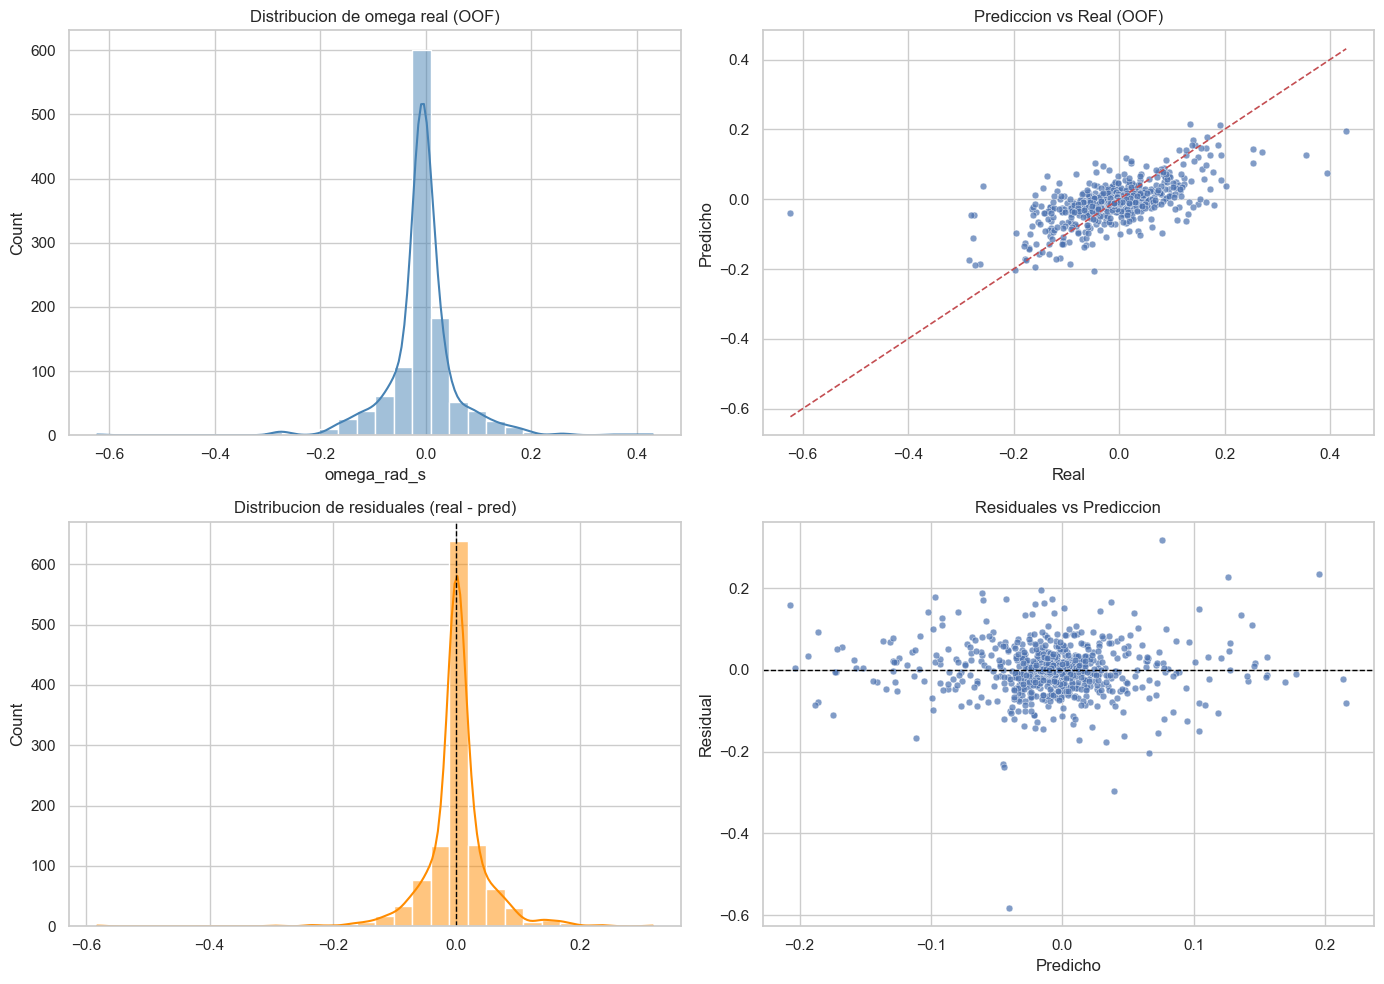

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Distribucion de y
sns.histplot(y_true_oof, bins=30, kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Distribucion de omega real (OOF)')
axes[0, 0].set_xlabel('omega_rad_s')

# 2) Prediccion vs real
sns.scatterplot(x=y_true_oof, y=y_pred_oof, s=24, alpha=0.7, ax=axes[0, 1])
min_v = float(min(y_true_oof.min(), y_pred_oof.min()))
max_v = float(max(y_true_oof.max(), y_pred_oof.max()))
axes[0, 1].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.2)
axes[0, 1].set_title('Prediccion vs Real (OOF)')
axes[0, 1].set_xlabel('Real')
axes[0, 1].set_ylabel('Predicho')

# 3) Histograma de residuales
residuals = y_true_oof - y_pred_oof
sns.histplot(residuals, bins=30, kde=True, ax=axes[1, 0], color='darkorange')
axes[1, 0].axvline(0.0, color='black', linestyle='--', linewidth=1)
axes[1, 0].set_title('Distribucion de residuales (real - pred)')

# 4) Residuales vs prediccion
sns.scatterplot(x=y_pred_oof, y=residuals, s=24, alpha=0.7, ax=axes[1, 1])
axes[1, 1].axhline(0.0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_title('Residuales vs Prediccion')
axes[1, 1].set_xlabel('Predicho')
axes[1, 1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

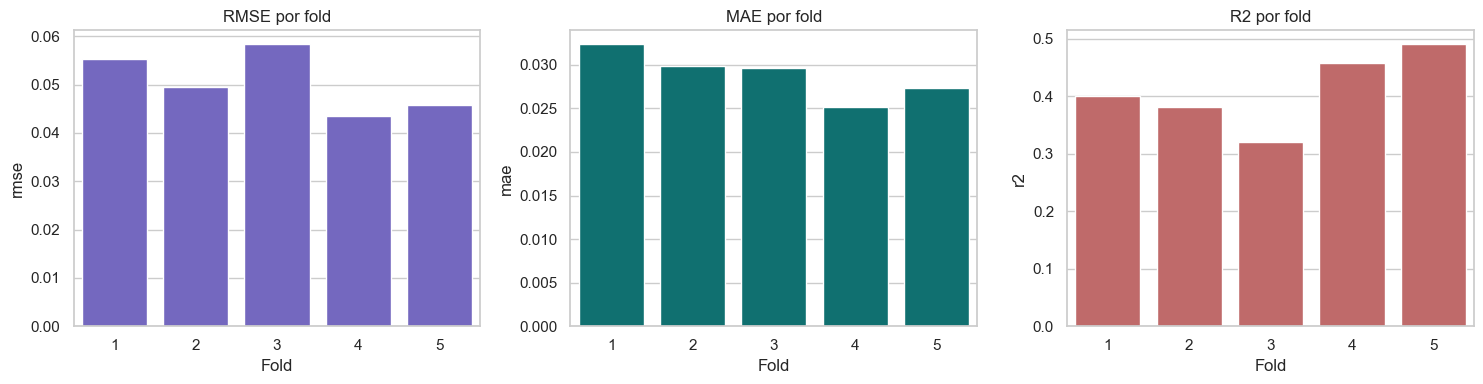

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=fold_metrics_df, x='fold', y='rmse', ax=axes[0], color='slateblue')
axes[0].set_title('RMSE por fold')

sns.barplot(data=fold_metrics_df, x='fold', y='mae', ax=axes[1], color='teal')
axes[1].set_title('MAE por fold')

sns.barplot(data=fold_metrics_df, x='fold', y='r2', ax=axes[2], color='indianred')
axes[2].set_title('R2 por fold')

for ax in axes:
    ax.set_xlabel('Fold')

plt.tight_layout()
plt.show()

## 4) Entrenamiento final y guardado de artefactos

Despues de validar K-Fold, se entrena un modelo final con todos los datos y se guarda en `output/results`.

In [8]:
final_model = RandomForestRegressor(
    n_estimators=400,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    min_samples_leaf=2,
)
final_model.fit(X, y)

MODEL_OUT.parent.mkdir(parents=True, exist_ok=True)
METRICS_OUT.parent.mkdir(parents=True, exist_ok=True)

artifact = {
    'model': final_model,
    'feature_columns': used_features,
    'target_name': 'omega_rad_s',
}
dump(artifact, MODEL_OUT)

metrics_payload = {
    'input_glob': INPUT_GLOB,
    'target_column': TARGET_COLUMN if TARGET_COLUMN is not None else 'auto',
    'n_samples': int(len(y_true_oof)),
    'n_features': int(X.shape[1]),
    'rmse_oof': overall_rmse,
    'mae_oof': overall_mae,
    'r2_oof': overall_r2,
    'fold_metrics': fold_rows,
    'feature_columns': used_features,
}
METRICS_OUT.write_text(json.dumps(metrics_payload, indent=2), encoding='utf-8')

print('Modelo guardado en:', MODEL_OUT)
print('Metricas guardadas en:', METRICS_OUT)

Modelo guardado en: C:\Users\alexc\Nextcloud\phd-AlexCastilla\code\LiDAR-Stability-algorithm\output\w_model_rf_notebook.joblib
Metricas guardadas en: C:\Users\alexc\Nextcloud\phd-AlexCastilla\code\LiDAR-Stability-algorithm\output\w_model_rf_notebook_metrics.json


,feature,importance
2,ax,0.378439
4,az,0.149277
3,ay,0.121865
0,roll,0.105156
1,pitch,0.090639
5,speed_kmh,0.047691
8,ruggedness,0.037061
7,tri,0.035327
6,phi_lidar,0.034545


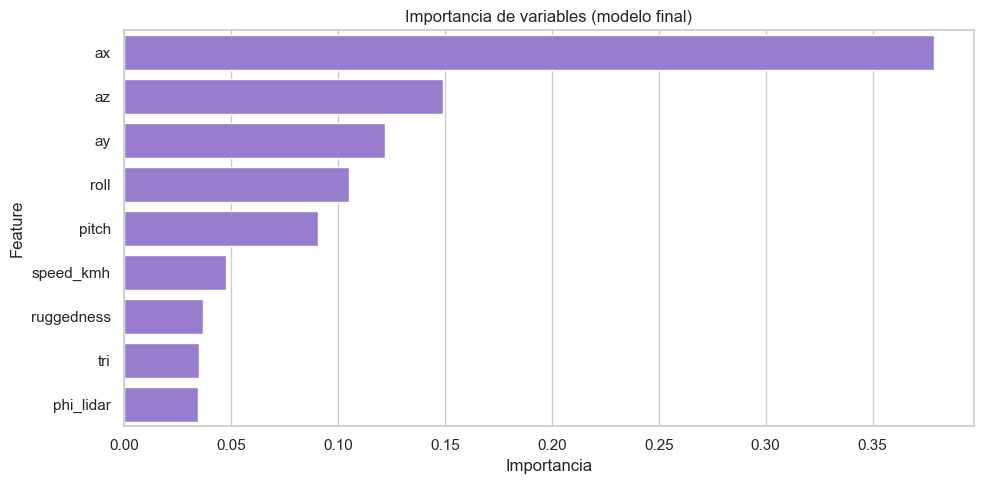

: 

In [ ]:
fi = pd.DataFrame({
    'feature': used_features,
    'importance': final_model.feature_importances_,
}).sort_values('importance', ascending=False)

display(fi)

plt.figure(figsize=(10, 5))
sns.barplot(data=fi, y='feature', x='importance', color='mediumpurple')
plt.title('Importancia de variables (modelo final)')
plt.xlabel('Importancia')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 5) Como usar este modelo en pipeline

Opciones recomendadas:

- Opcion notebook: repetir este flujo con un `INPUT_GLOB` mas amplio.
- Opcion script: usar el CLI oficial:

```bash
python Scripts/ml/train_w_model.py \
  --input-glob "Doback-Data/featured/DOBACK*.csv" \
  --output-model "output/results/w_model_rf.joblib" \
  --output-metrics "output/results/w_model_rf_metrics.json"
```

Y para generar GT enriquecido:

```bash
python Scripts/pipeline/build_enhanced_ground_truth.py \
  --input-glob "Doback-Data/featured/DOBACK*.csv" \
  --output-dir "output/results/enhanced-ground-truth" \
  --overwrite
```